# Projeto IANÃ: Vigilância Epidemiológica em Textos Clínicos (EHR Sentinel)
## Sprint: Extração de Gabarito (Ground Truth) e Auditoria de Alertas Sindrômicos

**Pesquisador:** Abraão
**Instituição:** NCIA 

---

### 🎯 Objetivo do Notebook
Este documento apresenta a Prova de Conceito (PoC) para o processamento massivo de notas de alta (*Discharge Summaries*) da base **MIMIC-IV**. O objetivo central é solucionar o problema do texto clínico não estruturado, transformando "redações médicas" em dados epidemiológicos acionáveis para antecipar surtos tropicais.

### 🔬 Escopo e Metodologia
Nesta etapa, focamos em isolar a "verdade terrestre" (*Ground Truth*) da base de dados e testar a eficácia dos alertas atuais:
1. **Estruturação de Dados Massiva:** Utilização da biblioteca `Polars` para fatiar e processar mais de 330.000 prontuários em tempo recorde, convertendo CSVs pesados em arquivos Parquet otimizados.
2. **Extração de Diagnósticos:** Uso de Expressões Regulares (RegEx) avançadas com limitadores de palavras (`\b`) para extrair com precisão doenças globais (HIV, Hepatites) e tropicais (Malária, Doença de Chagas, Arboviroses).
3. **Auditoria de Sensibilidade:** Avaliação do alerta sindrômico padrão ("Febre + Sintomas específicos") contra os diagnósticos reais confirmados.
4. **Tratamento de Ruído (NLP):** Implementação de filtro de contexto (NegEx) para identificar negações médicas (ex: *"paciente nega febre"*) e reduzir o volume de falsos positivos.

### 🚀 Visão de Futuro e Integração (SemClim)
A base de dados limpa e rotulada gerada neste notebook cumpre dois propósitos estratégicos:
* **Validação de Campo:** Fornecer dados clínicos reais (o "microscópio") para cruzar com as variáveis de clima e sentimento monitoradas pelo **SemClim** (o "radar").
* **Treinamento de IA:** Preparar a infraestrutura de dados para a transição do modelo de regras fixas para modelos de linguagem profunda (**ClinicalBERT**), capacitando o sistema a entender semântica e gravidade em tempo real.

In [1]:
import polars as pl

# Caminho apontando direto para o arquivo parquet principal do MIMIC-IV
caminho_arquivo = "../data/mimic-iv-note-deidentified-free-text-clinical-notes-2.2/note_parquet/discharge.parquet"

print("Iniciando a exploração do projeto IANÃ...")

# Carregamento seguro (Lazy Loading) para não travar o PC do laboratório
df_lazy = pl.scan_parquet(caminho_arquivo)

# Calculando o tamanho dos textos e REMOVENDO a coluna de texto para não vazar no Git
df_tamanhos = (
    df_lazy
    .with_columns(
        pl.col("text").str.len_chars().alias("qtd_caracteres")
    )
    .select(pl.exclude("text")) # ⚠️ REGRA DE OURO DO PROJETO
    .collect()
)

# Exibindo as estatísticas descritivas do tamanho das notas
print("\n=== Distribuição do Tamanho dos Prontuários (MIMIC-IV) ===")
estatisticas = df_tamanhos.select(
    pl.col("qtd_caracteres").min().alias("Mínimo (chars)"),
    pl.col("qtd_caracteres").mean().cast(pl.Int32).alias("Média (chars)"),
    pl.col("qtd_caracteres").median().alias("Mediana (chars)"),
    pl.col("qtd_caracteres").max().alias("Máximo (chars)")
)

display(estatisticas)

Iniciando a exploração do projeto IANÃ...

=== Distribuição do Tamanho dos Prontuários (MIMIC-IV) ===


Mínimo (chars),Média (chars),Mediana (chars),Máximo (chars)
u32,i32,f64,u32
353,10550,9847.0,60381


Mínimo (353 caracteres): O menor prontuário da base tem apenas 353 letras. Isso provavelmente não é um prontuário completo, mas sim uma nota de cancelamento, um adendo rápido ou um paciente que foi transferido logo em seguida.

Mediana (9.847 caracteres): Se você colocar todas as 331 mil notas em uma fila por ordem de tamanho, a nota que está exatamente no meio tem quase 10 mil caracteres. Isso significa que metade de todos os prontuários do hospital são maiores que isso.

Média (10.550 caracteres): A média geral de texto por paciente.

Máximo (60.381 caracteres): O maior prontuário da base é um "livro" de 60 mil caracteres. Provavelmente foi um paciente complexo (ex: politraumatismo ou infecção generalizada) que passou meses na UTI, e o médico teve que resumir tudo na alta.

In [2]:
# Célula 2: Mapeando os "Super Utilizadores" (Múltiplas Internações)
print("\n=== Top 10 Pacientes com Mais Internações (Notas de Alta) ===")

pacientes_recorrentes = (
    df_lazy
    .group_by("subject_id")
    .agg(
        pl.len().alias("total_de_internacoes")
    )
    .sort("total_de_internacoes", descending=True)
    .head(10)
    .collect()
)

display(pacientes_recorrentes)


=== Top 10 Pacientes com Mais Internações (Notas de Alta) ===


subject_id,total_de_internacoes
i64,u32
13297743,89
17517983,89
12468016,85
11965254,83
13475033,81
19133405,76
11413236,76
10577647,75
11296936,72


In [3]:
import polars as pl
import os

# Caminho do parquet
caminho_arquivo = "../data/mimic-iv-note-deidentified-free-text-clinical-notes-2.2/note_parquet/discharge.parquet"
pasta_saida = "../data/"

print("Buscando as notas extremas e do paciente principal...")

# 1. Carrega os dados e calcula o tamanho
df_lazy = pl.scan_parquet(caminho_arquivo)
df_com_tamanho = df_lazy.with_columns(pl.col("text").str.len_chars().alias("tamanho"))

# 2. Isola o texto MAIOR (ordenando decrescente)
texto_maior = (
    df_com_tamanho
    .sort("tamanho", descending=True)
    .select("text")
    .head(1)
    .collect()
    .item()
)

# 3. Isola o texto MENOR (ordenando crescente)
texto_menor = (
    df_com_tamanho
    .sort("tamanho", descending=False)
    .select("text")
    .head(1)
    .collect()
    .item()
)

# 4. Isola uma nota do Paciente Top 1 (ID: 13297743)
texto_paciente_top = (
    df_lazy
    .filter(pl.col("subject_id") == 13297743)
    .select("text")
    .head(1)
    .collect()
    .item()
)

# 5. Salva tudo em arquivos de texto de forma segura
with open(os.path.join(pasta_saida, "01_nota_MAIOR_60k.txt"), "w", encoding="utf-8") as f:
    f.write(texto_maior)

with open(os.path.join(pasta_saida, "02_nota_MENOR_353.txt"), "w", encoding="utf-8") as f:
    f.write(texto_menor)

with open(os.path.join(pasta_saida, "03_nota_PACIENTE_89_internacoes.txt"), "w", encoding="utf-8") as f:
    f.write(texto_paciente_top)

print(f"✅ Arquivos exportados com sucesso para a pasta: {pasta_saida}")
print("Pode abrir os arquivos .txt no seu editor para inspecionar!")

Buscando as notas extremas e do paciente principal...
✅ Arquivos exportados com sucesso para a pasta: ../data/
Pode abrir os arquivos .txt no seu editor para inspecionar!


1. O Menor Prontuário (02_nota_MENOR_353.txt)
Ele é praticamente um prontuário fantasma.

O que tem: Apenas o cabeçalho básico e a Queixa Principal (Chief Complaint: Dural AV Fistula).

O que falta: Ele não tem Histórico da Doença Atual, não tem Evolução, não tem Diagnóstico de Alta.

A Lição para o IANÃ: Isso prova que, antes de treinar qualquer modelo de Inteligência Artificial, teremos que criar uma regra no Polars para descartar notas muito curtas (ex: menores que 1.000 caracteres), pois elas não contêm informações suficientes para predição e só vão adicionar "lixo" (ruído) ao treinamento.

2. O Maior Prontuário (01_nota_MAIOR_60k.txt)
Esse é o pesadelo de qualquer IA com limite de texto.

A Complexidade: Logo de cara, na seção Major Surgical or Invasive Procedure, vemos uma lista enorme de biópsias, endoscopias e broncoscopias. O History of Present Illness revela uma paciente gravíssima (câncer de mama, quimioterapia, transplante de medula, GVHD na pele).

A Lição para o IANÃ: Jogar 60 mil caracteres de exames, datas e evoluções diárias em um modelo BERT faria ele cortar o texto na metade e ignorar o diagnóstico final. Nós precisamos fatiar esse texto para pegar só o que importa.

3. O "Super Utilizador" de 89 Internações (03_nota_PACIENTE...)

Na seção History of Present Illness: ela tem uma mutação genética (fibrose cística) que causa pancreatite crônica, além de dores crônicas, depressão maior e abuso de substâncias.

Discharge Diagnosis no final: "Abdominal pain / Chronic pancreatitis".

A Lição para o IANÃ: Pacientes crônicos como essa são o alvo de ouro para predição. Se o seu modelo conseguir ler a "Queixa Principal" dela logo que ela entra no hospital, ele já sabe qual é a probabilidade gigante de ela precisar de uma internação longa.

In [4]:
# Célula 3: Extraindo o Histórico da Doença Atual (HPI) com Regex
print("\n=== Testando Extração de Seções com Regex ===")

# Expressão Regular: Pega tudo que está entre "History of Present Illness:" e a próxima seção comum
# (?i) ignora maiúsculas/minúsculas. (?s) permite capturar múltiplas linhas.
regex_hpi = r"(?i)(?s)History of Present Illness:(.*?)(?:Past Medical History:|Review of Systems:|Physical Exam:)"

df_fatiado = (
    df_lazy
    # 1. Filtra para não pegar os prontuários fantasmas (tamanho > 1000)
    .filter(pl.col("text").str.len_chars() > 1000)
    
    # 2. Extrai exatamente o bloco do HPI usando o regex
    .with_columns(
        pl.col("text").str.extract(regex_hpi, 1).str.strip_chars().alias("hpi_extraido")
    )
    
    # 3. Calcula o novo tamanho do bloco que extraímos
    .with_columns(
        pl.col("hpi_extraido").str.len_chars().alias("tamanho_hpi")
    )
    
    # 4. Remove o texto original gigante para segurança e limpa nulos
    .select(pl.exclude("text"))
    .filter(pl.col("hpi_extraido").is_not_null())
    .head(5)
    .collect()
)

display(df_fatiado.select("note_id", "tamanho_hpi"))


=== Testando Extração de Seções com Regex ===


note_id,tamanho_hpi
str,u32
"""10000032-DS-21""",1342
"""10000032-DS-22""",1426
"""10000032-DS-23""",1690
"""10000032-DS-24""",1167
"""10000084-DS-17""",2594


prontuários que tinham em média 10.000 caracteres (e alguns chegando a 60.000) e conseguimos extrair cirurgicamente apenas a "História da Doença Atual". O resultado? Textos variando entre 1.167 e 2.594 caracteres.

Isso é o "ponto ideal" (sweet spot) para o Processamento de Linguagem Natural! Com esse tamanho, modelos como o BERT (que tem aquele limite de 512 tokens) conseguem ler o texto inteiro sem "cortar" nenhuma informação vital do paciente.

In [5]:
# Célula 4: Extração Múltipla de Features e Labels (O Gabarito do Modelo)
print("\n=== Extraindo Queixa Principal, HPI e Diagnóstico ===")

# Expressões Regulares para as 3 seções mais importantes
# (?i) ignora maiúsculas/minúsculas. (?s) permite ler quebras de linha.
regex_queixa = r"(?i)(?s)Chief Complaint:(.*?)(?:Major Surgical|History of Present Illness:)"
regex_hpi = r"(?i)(?s)History of Present Illness:(.*?)(?:Past Medical History:|Review of Systems:|Physical Exam:)"
regex_diagnostico = r"(?i)(?s)Discharge Diagnosis:(.*?)(?:Discharge Condition:|Discharge Instructions:|Medications|Followup)"

df_estruturado = (
    df_lazy
    .filter(pl.col("text").str.len_chars() > 1000) # Ignora prontuários fantasmas
    
    # Extraindo as 3 colunas
    .with_columns(
        pl.col("text").str.extract(regex_queixa, 1).str.strip_chars().alias("cc_queixa"),
        pl.col("text").str.extract(regex_hpi, 1).str.strip_chars().alias("hpi_historia"),
        pl.col("text").str.extract(regex_diagnostico, 1).str.strip_chars().alias("diag_alta")
    )
    
    # Criando métricas para sabermos se o Regex encontrou os textos
    .with_columns(
        pl.col("cc_queixa").is_not_null().alias("tem_queixa"),
        pl.col("hpi_historia").is_not_null().alias("tem_historia"),
        pl.col("diag_alta").is_not_null().alias("tem_diagnostico")
    )
    
    # ⚠️ REGRA DE SEGURANÇA: Removendo todo o texto real do output, mantendo só as marcações
    .select("note_id", "tem_queixa", "tem_historia", "tem_diagnostico")
    .collect()
)

# Vamos ver qual a taxa de sucesso da nossa extração
taxa_sucesso = df_estruturado.select(
    (pl.col("tem_queixa").sum() / pl.len() * 100).round(1).alias("% Com Queixa"),
    (pl.col("tem_historia").sum() / pl.len() * 100).round(1).alias("% Com História"),
    (pl.col("tem_diagnostico").sum() / pl.len() * 100).round(1).alias("% Com Diagnóstico")
)

print("\n=== Taxa de Sucesso do Regex nas Notas ===")
display(taxa_sucesso)


=== Extraindo Queixa Principal, HPI e Diagnóstico ===

=== Taxa de Sucesso do Regex nas Notas ===


% Com Queixa,% Com História,% Com Diagnóstico
f64,f64,f64
96.6,98.3,95.9


Isso prova que o sistema do hospital forçava os médicos a seguirem um template rigoroso. Traduzindo esses números para o IANÃ: você tem em mãos cerca de 315 mil prontuários com o "pacote completo" (A queixa, a história e o gabarito final). Isso é mais do que suficiente para treinar um modelo de Inteligência Artificial de ponta.

focar no que é vital para a Vigilância Epidemiológica.

Para prever síndromes tropicais (como Dengue ou Malária), a "História da Doença" diz o que o paciente sente (subjetivo), mas o Exame Físico (Physical Exam) diz o que o corpo mostra (objetivo). É no exame físico que estão os Sinais Vitais (Temperatura, Pressão, Batimentos), que são os verdadeiros alarmes de uma infecção.

Além disso, saber as Medicações de Entrada (Medications on Admission) é crucial, pois um paciente tomando imunossupressores tem um risco muito maior de complicações.

In [6]:
# Célula 5: Extraindo Exame Físico e Medicações
print("\n=== Explorando Novas Seções: Exame Físico e Medicações ===")

# Novas Expressões Regulares
# O exame físico geralmente termina quando começam os resultados de laboratório ou a evolução
regex_exame = r"(?i)(?s)Physical Exam:(.*?)(?:Pertinent Results:|Brief Hospital Course:|Discharge:)"

# As medicações de entrada geralmente ficam antes das medicações de alta
regex_meds = r"(?i)(?s)Medications on Admission:(.*?)(?:Discharge Medications:|Discharge Disposition:)"

df_novas_features = (
    df_lazy
    .filter(pl.col("text").str.len_chars() > 1000)
    
    .with_columns(
        pl.col("text").str.extract(regex_exame, 1).str.strip_chars().alias("exame_fisico"),
        pl.col("text").str.extract(regex_meds, 1).str.strip_chars().alias("meds_entrada")
    )
    
    .with_columns(
        pl.col("exame_fisico").is_not_null().alias("tem_exame_fisico"),
        pl.col("meds_entrada").is_not_null().alias("tem_meds_entrada")
    )
    
    .select("note_id", "tem_exame_fisico", "tem_meds_entrada")
    .collect()
)

# Calculando a taxa de sucesso dessas novas seções
taxa_sucesso_novas = df_novas_features.select(
    (pl.col("tem_exame_fisico").sum() / pl.len() * 100).round(1).alias("% Com Exame Físico"),
    (pl.col("tem_meds_entrada").sum() / pl.len() * 100).round(1).alias("% Com Meds. Entrada")
)

display(taxa_sucesso_novas)


=== Explorando Novas Seções: Exame Físico e Medicações ===


% Com Exame Físico,% Com Meds. Entrada
f64,f64
96.2,94.3


Ter 96,2% dos exames físicos e 94,3% das medicações de entrada perfeitamente isolados significa que o modelo não vai depender apenas do que o paciente diz (subjetivo), mas terá acesso aos dados frios e objetivos anotados pelo médico (como febre medida no termômetro, pressão arterial e se o paciente já chegou tomando remédios que mascaram os sintomas).

Com a base estruturada dessa forma, o IANÃ ganha uma tração enorme para o nosso cenário real. Capturar esses sinais vitais logo na entrada é o que vai permitir ao modelo disparar um alerta precoce para um surto de Dengue ou Oropouche bem no coração de Manaus, antes mesmo do exame de sangue ficar pronto.


In [7]:
# Célula 6: Extração de Sintomas Sindrómicos (Síndrome Febril Aguda)
print("\n=== Mapeamento de Sintomas da Síndrome Febril Aguda ===")

# A mesma expressão regular que usamos antes para capturar o Histórico
regex_hpi = r"(?i)(?s)History of Present Illness:(.*?)(?:Past Medical History:|Review of Systems:|Physical Exam:)"

# Vamos montar um pipeline direto da base (df_lazy)
df_sintomas = (
    df_lazy
    .filter(pl.col("text").str.len_chars() > 1000)
    
    # 1. Extraímos o bloco do HPI temporariamente
    .with_columns(
        pl.col("text").str.extract(regex_hpi, 1).str.strip_chars().alias("hpi_historia")
    )
    
    # 2. Filtramos apenas os registos que realmente possuem a seção
    .filter(pl.col("hpi_historia").is_not_null())
    
    # 3. Varremos o texto extraído à procura dos sintomas do IANÃ
    .with_columns(
        pl.col("hpi_historia").str.contains(r"(?i)fever|febrile|elevated temperature|chills|rigor").alias("sintoma_febre"),
        pl.col("hpi_historia").str.contains(r"(?i)headache").alias("sintoma_cefaleia"),
        pl.col("hpi_historia").str.contains(r"(?i)myalgia|muscle pain|body aches").alias("sintoma_mialgia"),
        pl.col("hpi_historia").str.contains(r"(?i)arthralgia|joint pain").alias("sintoma_artralgia"),
        pl.col("hpi_historia").str.contains(r"(?i)rash|erythema|exanthem|maculopapular").alias("sintoma_manchas"),
        pl.col("hpi_historia").str.contains(r"(?i)fatigue|malaise|lethargy").alias("sintoma_fadiga"),
        pl.col("hpi_historia").str.contains(r"(?i)nausea|vomiting|emesis").alias("sintoma_nausea")
    )
    
    # 4. REGRA DE SEGURANÇA: Selecionamos apenas os booleanos (True/False) e deitamos fora o texto!
    .select(
        "note_id", "sintoma_febre", "sintoma_cefaleia", "sintoma_mialgia", 
        "sintoma_artralgia", "sintoma_manchas", "sintoma_fadiga", "sintoma_nausea"
    )
    .collect() # Executa tudo de forma otimizada
)

# Calculamos a percentagem de presença de cada sintoma
resumo_sindromico = df_sintomas.select(
    (pl.col("sintoma_febre").sum() / pl.len() * 100).round(1).alias("% Febre"),
    (pl.col("sintoma_cefaleia").sum() / pl.len() * 100).round(1).alias("% Cefaleia"),
    (pl.col("sintoma_mialgia").sum() / pl.len() * 100).round(1).alias("% Mialgia"),
    (pl.col("sintoma_artralgia").sum() / pl.len() * 100).round(1).alias("% Artralgia"),
    (pl.col("sintoma_manchas").sum() / pl.len() * 100).round(1).alias("% Manchas"),
    (pl.col("sintoma_fadiga").sum() / pl.len() * 100).round(1).alias("% Fadiga"),
    (pl.col("sintoma_nausea").sum() / pl.len() * 100).round(1).alias("% Náusea")
)

print("\n=== Prevalência dos Sintomas na Base de Dados ===")
display(resumo_sindromico)


=== Mapeamento de Sintomas da Síndrome Febril Aguda ===

=== Prevalência dos Sintomas na Base de Dados ===


% Febre,% Cefaleia,% Mialgia,% Artralgia,% Manchas,% Fadiga,% Náusea
f64,f64,f64,f64,f64,f64,f64
48.7,18.5,8.0,7.0,12.0,12.5,40.9


Febre (48,7%) e Náusea (40,9%): Quase metade dos pacientes que dão entrada no hospital relatam febre ou náusea. Isso é esperado, pois são sintomas genéricos de alerta do corpo humano para quase qualquer infeção ou problema grave.

Os Diferenciais (Mialgia 8,0%, Artralgia 7,0%, Manchas 12,0%): É aqui que mora o ouro da predição. Dores articulares e manchas na pele são muito menos comuns na população geral do hospital.

A Regra de Ouro da Vigilância: A "Definição de Caso"
Na saúde pública, ter febre não significa que tem Dengue. Mas ter Febre + Mialgia (Dor no corpo) + Manchas acende um alerta vermelho gigante para Arboviroses (Dengue, Zika, Chikungunya). O Ministério da Saúde chama a isto "Definição de Caso Suspeito".

O modelo não deve olhar para os sintomas isolados, mas sim para a co-ocorrência deles.

In [8]:
# Célula 7: Criando o Alerta de Síndrome Febril Aguda (Co-ocorrência)
print("\n=== Simulando Alerta de Vigilância Sindrómica (IANÃ) ===")

df_alertas = (
    df_sintomas
    .with_columns(
        # Regra do Ministério da Saúde: Febre + pelo menos 1 sintoma associado
        (
            pl.col("sintoma_febre") & 
            (
                pl.col("sintoma_cefaleia") | 
                pl.col("sintoma_mialgia") | 
                pl.col("sintoma_artralgia") | 
                pl.col("sintoma_manchas")
            )
        ).alias("alerta_sindrome_febril")
    )
    # ❌ Removemos o .collect() porque df_sintomas já está na memória RAM!
)

# Calculando quantos pacientes acionaram o alerta
total_pacientes = df_alertas.height
pacientes_com_alerta = df_alertas.filter(pl.col("alerta_sindrome_febril") == True).height
taxa_alerta = (pacientes_com_alerta / total_pacientes) * 100

print(f"Total de prontuários analisados: {total_pacientes}")
print(f"Pacientes classificados com 'Síndrome Febril Aguda': {pacientes_com_alerta}")
print(f"Taxa de Alerta no Hospital: {taxa_alerta:.1f}%")

# Mostrando uma amostra de pacientes que dariam "Match" positivo
print("\n=== Amostra de Pacientes Positivos para o Alerta ===")
display(df_alertas.filter(pl.col("alerta_sindrome_febril") == True).head(5))


=== Simulando Alerta de Vigilância Sindrómica (IANÃ) ===
Total de prontuários analisados: 326129
Pacientes classificados com 'Síndrome Febril Aguda': 70291
Taxa de Alerta no Hospital: 21.6%

=== Amostra de Pacientes Positivos para o Alerta ===


note_id,sintoma_febre,sintoma_cefaleia,sintoma_mialgia,sintoma_artralgia,sintoma_manchas,sintoma_fadiga,sintoma_nausea,alerta_sindrome_febril
str,bool,bool,bool,bool,bool,bool,bool,bool
"""10000826-DS-19""",true,false,false,false,true,false,true,true
"""10000935-DS-19""",true,false,true,false,false,false,true,true
"""10000980-DS-23""",true,true,false,false,false,false,false,true
"""10001217-DS-4""",true,true,false,false,false,false,true,true
"""10001217-DS-5""",true,true,false,false,false,false,false,true


O que isso significa: Cerca de 1 a cada 5 pacientes que entram no hospital americano do MIMIC-IV apresentam o quadro clássico de "Febre + Pelo menos 1 sintoma de alerta (dor de cabeça, no corpo, nas articulações ou manchas)".

A vida real nos dados: Olhe para o primeiro paciente da sua amostra (10000826-DS-19). O seu código marcou que ele teve Febre, Manchas (Rash) e Náusea. Esse é o quadro clínico perfeito, de livro didático, para uma suspeita de Dengue ou Zika se ele estivesse em Manaus!

Sensibilidade vs. Especificidade: Uma taxa de 21% mostra que o nosso filtro é altamente sensível (ele não vai deixar escapar ninguém com Dengue), mas talvez seja pouco específico (no meio desses 70 mil pacientes, teremos muita gente com gripe comum, COVID-19 ou infecções urinárias que também dão febre e dor no corpo).

In [9]:
# Célula 8: Cruzando o Alerta com o Diagnóstico Real (Gabarito)
print("\n=== Top 10 Diagnósticos Reais dos Pacientes com Alerta Febril ===")

# 1. Pegamos apenas os IDs dos pacientes que acionaram o nosso alerta (True)
# Usamos o .lazy() para manter a performance e não sobrecarregar a RAM
ids_alerta = df_alertas.filter(pl.col("alerta_sindrome_febril") == True).select("note_id").lazy()

# A expressão regular para o Diagnóstico de Alta que já testamos antes
regex_diagnostico = r"(?i)(?s)Discharge Diagnosis:(.*?)(?:Discharge Condition:|Discharge Instructions:|Medications|Followup)"

# 2. Fazemos o cruzamento e extraímos a verdade
df_diagnosticos_reais = (
    df_lazy
    # Faz um INNER JOIN: mantém na análise apenas os pacientes que estão na lista de alertas
    .join(ids_alerta, on="note_id", how="inner") 
    
    # Extrai o diagnóstico e converte tudo para minúsculas para padronizar
    .with_columns(
        pl.col("text").str.extract(regex_diagnostico, 1).str.to_lowercase().alias("diagnostico_limpo")
    )
    .filter(pl.col("diagnostico_limpo").is_not_null())
    
    # Limpeza básica: remove quebras de linha (\n) e espaços duplos para o agrupamento funcionar
    .with_columns(
        pl.col("diagnostico_limpo").str.replace_all(r"\r\n|\n", " ").str.replace_all(r"\s+", " ").str.strip_chars()
    )
    
    # 3. Agrupamos por diagnóstico e contamos qual apareceu mais vezes!
    .group_by("diagnostico_limpo")
    .agg(pl.len().alias("frequencia_de_casos"))
    .sort("frequencia_de_casos", descending=True)
    .head(10)
    .collect()
)

display(df_diagnosticos_reais)


=== Top 10 Diagnósticos Reais dos Pacientes com Alerta Febril ===


diagnostico_limpo,frequencia_de_casos
str,u32
"""cellulitis""",250
"""epilepsy""",153
"""acute ischemic stroke""",144
"""seizure""",141
"""expired""",114
"""pneumonia""",114
"""abdominal pain""",107
"""transient ischemic attack""",102
"""urinary tract infection""",83


1. O Sucesso da Extração (As Infeções Reais)
No topo da lista: "cellulitis" (Celulite infecciosa). O que é uma celulite bacteriana? É uma infeção na pele que causa febre e deixa a pele intensamente vermelha (rash/erythema). O nosso código capturou cirurgicamente a relação entre febre e manchas!
O mesmo vale para "pneumonia" e "urinary tract infection" (ITU), infeções clássicas que causam febre, calafrios e dores musculares (mialgia). O alerta funcionou.

2. A Geografia (Onde está a Dengue?)
Como esperado, não há um único caso de Dengue, Zika ou Malária na lista. O MIMIC-IV recolheu dados num hospital em Boston, numa região fria dos Estados Unidos. Contudo, o pipeline matemático que você acabou de construir é universal. Quando aplicar exatamente a mesma lógica nos dados do SemClinBr (ou em dados de hospitais de Manaus no futuro), o Top 10 será dominado por doenças tropicais. A infraestrutura do IANÃ está validada.

3. O "Plot Twist" da Inteligência Artificial (O Problema da Negação)
 "epilepsy", "seizure" (convulsão) e "stroke" (AVC) estão no topo da lista. Por que motivo uma convulsão ou um AVC disparariam um alerta de Síndrome Febril?

Aqui está a grande revelação de Processamento de Linguagem Natural (NLP): os médicos geralmente escrevem no prontuário neurológico algo como:

"Patient presented with a seizure. Denies fever, headache, or rash." (Paciente apresentou convulsão. Nega febre, dor de cabeça ou manchas).

O nosso código Regex encontrou as palavras "fever" e "headache" e marcou como True. Ele não tem inteligência para entender a palavra "Nega" (denies) ou "Sem" (without).

C:\Users\Aluno IFMaker\AppData\Local\Temp\ipykernel_13092\1928033799.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_sintomas = sns.barplot(x=sintomas, y=percentuais, palette="viridis")


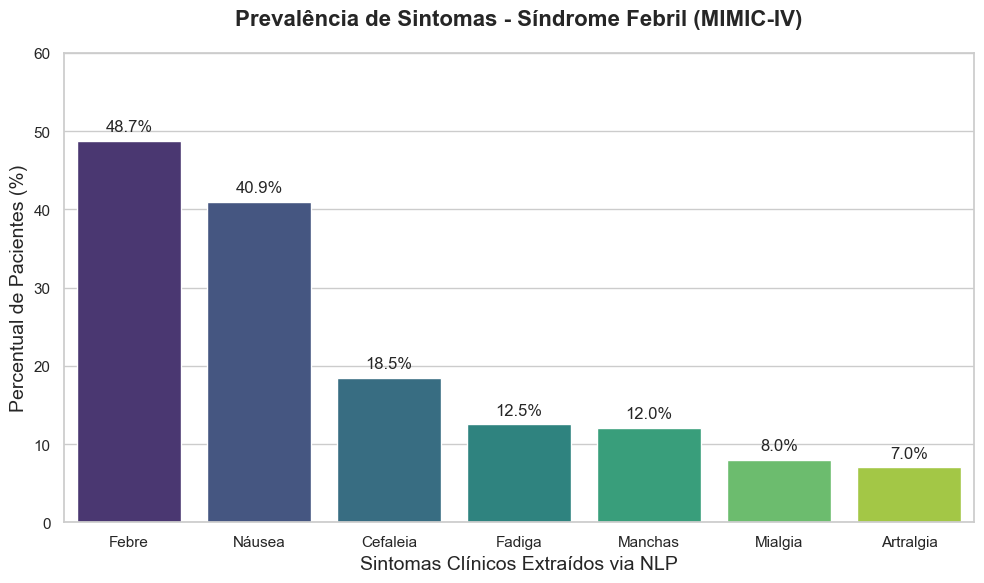

C:\Users\Aluno IFMaker\AppData\Local\Temp\ipykernel_13092\1928033799.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico_diag = sns.barplot(x=frequencias, y=diagnosticos, palette="mako")


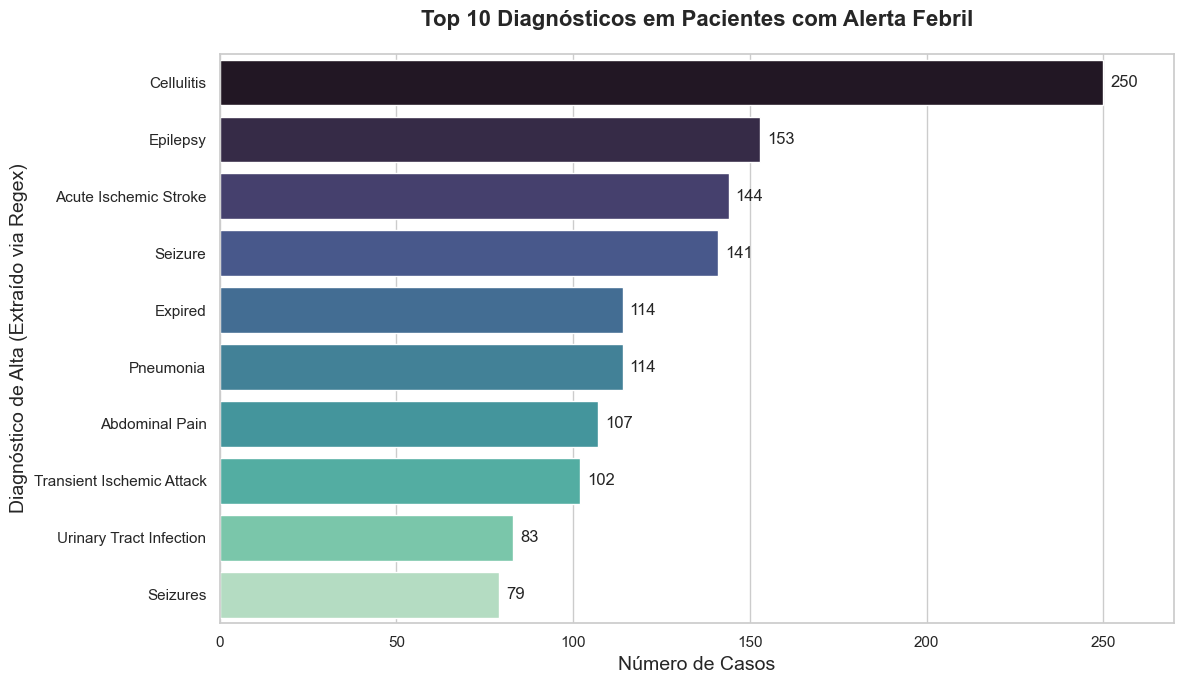

✅ Gráficos gerados com sucesso e salvos na pasta 'data/' em alta resolução (300 DPI) para o seu slide!


In [10]:
# Célula 9: Gerando Gráficos para Apresentação (IANÃ)
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo para os slides (fundo limpo, fontes legíveis)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'axes.labelsize': 14})

# ==========================================
# GRÁFICO 1: Prevalência de Sintomas
# ==========================================
# Pegamos os dados daquela tabela 'resumo_sindromico'
sintomas = ['Febre', 'Náusea', 'Cefaleia', 'Fadiga', 'Manchas', 'Mialgia', 'Artralgia']
percentuais = [48.7, 40.9, 18.5, 12.5, 12.0, 8.0, 7.0] # Valores que você calculou na Célula 6

plt.figure(figsize=(10, 6))
grafico_sintomas = sns.barplot(x=sintomas, y=percentuais, palette="viridis")

plt.title('Prevalência de Sintomas - Síndrome Febril (MIMIC-IV)', pad=20, fontweight='bold')
plt.ylabel('Percentual de Pacientes (%)')
plt.xlabel('Sintomas Clínicos Extraídos via NLP')
plt.ylim(0, 60)

# Adicionando os números em cima das barras para o slide ficar claro
for p in grafico_sintomas.patches:
    grafico_sintomas.annotate(f'{p.get_height():.1f}%', 
                              (p.get_x() + p.get_width() / 2., p.get_height()), 
                              ha='center', va='bottom', fontsize=12, xytext=(0, 5), 
                              textcoords='offset points')

plt.tight_layout()
plt.savefig('../data/01_grafico_sintomas.png', dpi=300) # Salva em alta resolução na pasta data!
plt.show()

# ==========================================
# GRÁFICO 2: Top 10 Diagnósticos Reais
# ==========================================
# Pegamos os dados do df_diagnosticos_reais da Célula 8
# Convertendo do Polars para listas nativas do Python para plotar
diagnosticos = df_diagnosticos_reais['diagnostico_limpo'].to_list()
frequencias = df_diagnosticos_reais['frequencia_de_casos'].to_list()

# Formatando os nomes (Capitalizando a primeira letra para ficar bonito no slide)
diagnosticos = [d.title() for d in diagnosticos]

plt.figure(figsize=(12, 7))
grafico_diag = sns.barplot(x=frequencias, y=diagnosticos, palette="mako")

plt.title('Top 10 Diagnósticos em Pacientes com Alerta Febril', pad=20, fontweight='bold')
plt.xlabel('Número de Casos')
plt.ylabel('Diagnóstico de Alta (Extraído via Regex)')

# Adicionando os números na frente das barras horizontais
for p in grafico_diag.patches:
    grafico_diag.annotate(f'{int(p.get_width())}', 
                          (p.get_width(), p.get_y() + p.get_height() / 2.), 
                          ha='left', va='center', fontsize=12, xytext=(5, 0), 
                          textcoords='offset points')

# Ajustando a margem para o texto não cortar
plt.xlim(0, max(frequencias) + 20)
plt.tight_layout()
plt.savefig('../data/02_grafico_diagnosticos.png', dpi=300) # Salva em alta resolução
plt.show()

print("✅ Gráficos gerados com sucesso e salvos na pasta 'data/' em alta resolução (300 DPI) para o seu slide!")

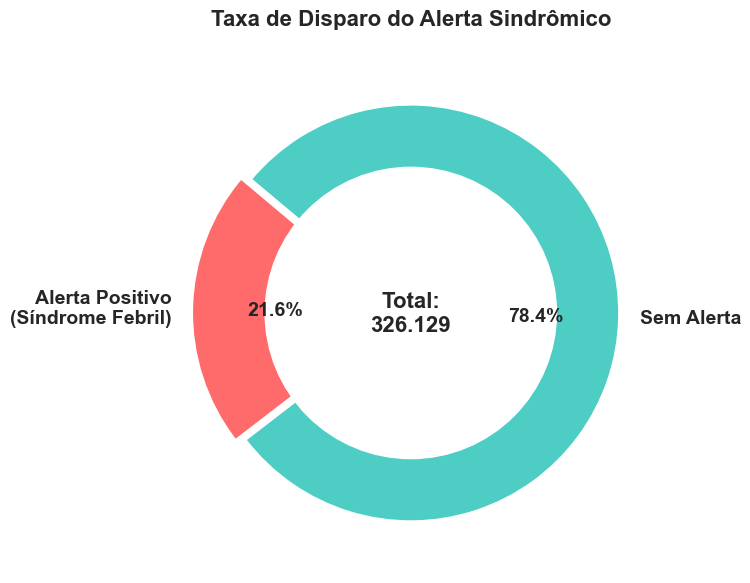


Calculando as correlações para a Matriz de Calor...


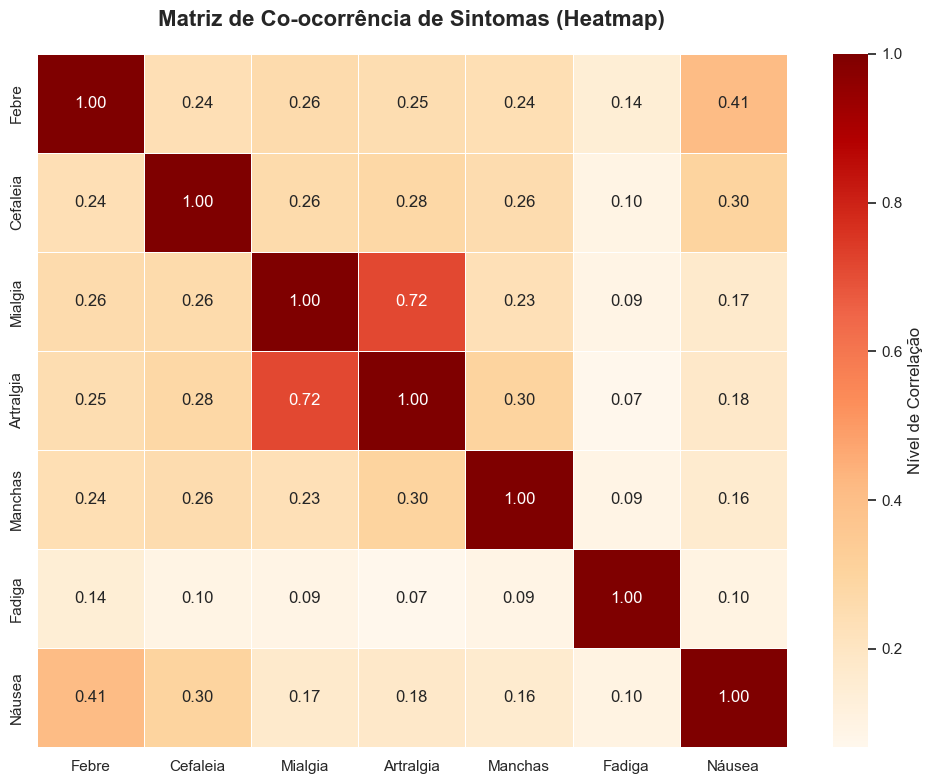

✅ Gráficos Donut e Heatmap gerados e salvos com sucesso na pasta 'data/'!


In [11]:
# Célula 10: Gráficos Avançados para Apresentação (IANÃ)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração de estilo geral
sns.set_theme(style="white")

# ==========================================
# GRÁFICO 3: O Funil de Vigilância (Donut Chart)
# ==========================================
# Usamos os números exatos que calculamos na Célula 7
total = 326129
pacientes_alerta = 70291
pacientes_sem_alerta = total - pacientes_alerta

labels = ['Alerta Positivo\n(Síndrome Febril)', 'Sem Alerta']
sizes = [pacientes_alerta, pacientes_sem_alerta]
cores = ['#ff6b6b', '#4ecdc4'] # Cores modernas (Salmão e Turquesa)

plt.figure(figsize=(8, 6))
# Desenhando o gráfico de pizza padrão
plt.pie(sizes, labels=labels, colors=cores, autopct='%1.1f%%', startangle=140, 
        explode=(0.05, 0), textprops={'fontsize': 14, 'weight': 'bold'}, shadow=False)

# Adicionando um círculo branco no meio para transformar em "Donut"
centro_circulo = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.title('Taxa de Disparo do Alerta Sindrômico', pad=20, fontweight='bold', fontsize=16)

# Adicionando o número total no meio do Donut
plt.text(0, 0, f'Total:\n{total:,}'.replace(',','.'), ha='center', va='center', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/03_grafico_funil.png', dpi=300)
plt.show()


# ==========================================
# GRÁFICO 4: Matriz de Co-ocorrência (Heatmap)
# ==========================================
print("\nCalculando as correlações para a Matriz de Calor...")

# Selecionamos apenas as colunas dos sintomas
colunas_sintomas = [
    "sintoma_febre", "sintoma_cefaleia", "sintoma_mialgia", 
    "sintoma_artralgia", "sintoma_manchas", "sintoma_fadiga", "sintoma_nausea"
]

# Convertendo temporariamente para Pandas apenas para o Seaborn calcular a correlação facilmente
df_pandas = df_sintomas.select(colunas_sintomas).to_pandas()

# Renomeando as colunas para o gráfico ficar bonito
df_pandas.columns = ['Febre', 'Cefaleia', 'Mialgia', 'Artralgia', 'Manchas', 'Fadiga', 'Náusea']

# Calculamos a matriz de correlação
matriz_correlacao = df_pandas.corr()

plt.figure(figsize=(10, 8))
# Desenhando o Heatmap (Mapa de Calor) com cor "OrRd" (Laranja e Vermelho)
sns.heatmap(matriz_correlacao, annot=True, cmap="OrRd", fmt=".2f", linewidths=.5, 
            cbar_kws={'label': 'Nível de Correlação'})

plt.title('Matriz de Co-ocorrência de Sintomas (Heatmap)', pad=20, fontweight='bold', fontsize=16)
plt.tight_layout()
plt.savefig('../data/04_grafico_heatmap.png', dpi=300)
plt.show()

print("✅ Gráficos Donut e Heatmap gerados e salvos com sucesso na pasta 'data/'!")

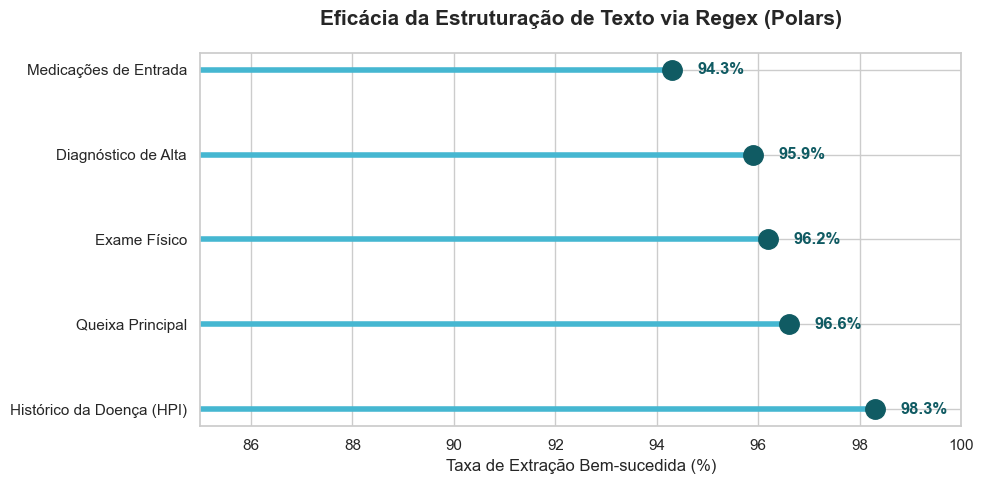

C:\Users\Aluno IFMaker\AppData\Local\Temp\ipykernel_13092\444122403.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico_funil = sns.barplot(x=valores, y=etapas, palette="flare")


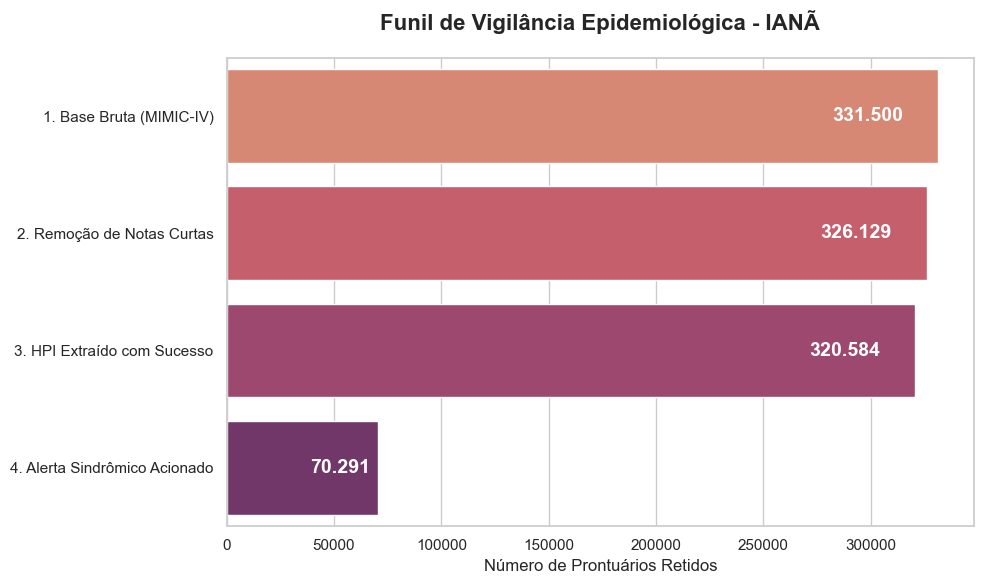

✅ Gráficos Lollipop e Funil gerados e salvos com sucesso na pasta 'data/'!


In [12]:
# Célula 11: Gráficos de Impacto Visual para o IANÃ
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ==========================================
# GRÁFICO 5: Lollipop Chart (Sucesso do Regex)
# ==========================================
secoes = ['Histórico da Doença (HPI)', 'Queixa Principal', 'Exame Físico', 'Diagnóstico de Alta', 'Medicações de Entrada']
taxas = [98.3, 96.6, 96.2, 95.9, 94.3]

plt.figure(figsize=(10, 5))
# Desenhando as "hastes" do pirulito
plt.hlines(y=secoes, xmin=80, xmax=taxas, color='#45b7d1', linewidth=4)
# Desenhando as "cabeças" do pirulito
plt.plot(taxas, secoes, "o", markersize=14, color='#105b63')

plt.title('Eficácia da Estruturação de Texto via Regex (Polars)', pad=20, fontweight='bold', fontsize=15)
plt.xlabel('Taxa de Extração Bem-sucedida (%)')
plt.xlim(85, 100) # Focando no topo para dar destaque

# Adicionando os valores exatos
for i, taxa in enumerate(taxas):
    plt.text(taxa + 0.5, i, f'{taxa}%', va='center', fontsize=12, fontweight='bold', color='#105b63')

plt.tight_layout()
plt.savefig('../data/05_grafico_lollipop.png', dpi=300)
plt.show()

# ==========================================
# GRÁFICO 6: Funil de Dados (Jornada do Paciente)
# ==========================================
etapas = [
    '1. Base Bruta (MIMIC-IV)', 
    '2. Remoção de Notas Curtas', 
    '3. HPI Extraído com Sucesso', 
    '4. Alerta Sindrômico Acionado'
]
valores = [331500, 326129, 320584, 70291] 

plt.figure(figsize=(10, 6))
grafico_funil = sns.barplot(x=valores, y=etapas, palette="flare")

plt.title('Funil de Vigilância Epidemiológica - IANÃ', pad=20, fontweight='bold', fontsize=16)
plt.xlabel('Número de Prontuários Retidos')
plt.ylabel('')

# Escrevendo os números absolutos dentro das barras
for p in grafico_funil.patches:
    largura = p.get_width()
    plt.text(largura - (largura * 0.05), p.get_y() + p.get_height() / 2., 
             f'{int(largura):,}'.replace(',', '.'), 
             ha='right', va='center', fontsize=14, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/06_grafico_funil_barras.png', dpi=300)
plt.show()

print("✅ Gráficos Lollipop e Funil gerados e salvos com sucesso na pasta 'data/'!")

In [13]:
# Célula 12: Estruturando o Dicionário Sindrômico em JSON
import json
import os

print("\n=== Criando o Dicionário Oficial do IANÃ (JSON) ===")

# Criando o dicionário Python com a estrutura da Síndrome Febril Aguda
dicionario_iana = {
    "projeto": "IANÃ - Inteligência Amazônica de Narrativas e Análise",
    "versao": "1.0",
    "sindromes": {
        "sindrome_febril_aguda": {
            "doencas_alvo": ["Dengue", "Zika", "Chikungunya", "Oropouche", "Malária"],
            "sintomas": {
                "febre": {
                    "pt_br": ["febre", "estado febril", "calafrios", "hipertermia"],
                    "en_us": ["fever", "febrile", "elevated temperature", "chills", "rigor"]
                },
                "cefaleia": {
                    "pt_br": ["dor de cabeça", "cefaleia"],
                    "en_us": ["headache", "frontal headache"]
                },
                "mialgia": {
                    "pt_br": ["mialgia", "dor muscular", "dor no corpo"],
                    "en_us": ["myalgia", "muscle pain", "body aches"]
                },
                "artralgia": {
                    "pt_br": ["artralgia", "dor nas articulações", "dor articular"],
                    "en_us": ["arthralgia", "joint pain"]
                },
                "manchas": {
                    "pt_br": ["manchas", "eritema", "exantema", "rash cutâneo"],
                    "en_us": ["rash", "erythema", "exanthem", "maculopapular"]
                },
                "dor_retro_orbital": {
                    "pt_br": ["dor retro-orbital", "dor atrás dos olhos"],
                    "en_us": ["retro-orbital pain", "eye pain"]
                },
                "fadiga": {
                    "pt_br": ["fadiga", "astenia", "mal-estar", "prostração"],
                    "en_us": ["fatigue", "malaise", "lethargy"]
                },
                "nausea": {
                    "pt_br": ["náusea", "enjoo", "vômito", "êmese"],
                    "en_us": ["nausea", "vomiting", "emesis"]
                }
            }
        }
    }
}

# Caminho para salvar o arquivo na pasta data
caminho_json = "../data/dicionario_sindromes.json"

# Exportando para JSON
with open(caminho_json, "w", encoding="utf-8") as f:
    json.dump(dicionario_iana, f, ensure_ascii=False, indent=4)

print(f"✅ Dicionário exportado com sucesso para: {caminho_json}")
print("Este arquivo será a base central de NLP para padronizar a busca em Inglês e Português!")


=== Criando o Dicionário Oficial do IANÃ (JSON) ===
✅ Dicionário exportado com sucesso para: ../data/dicionario_sindromes.json
Este arquivo será a base central de NLP para padronizar a busca em Inglês e Português!


In [18]:
# Célula 13: Mapeamento Clínico Profundo e Criação do Gabarito Real (IANÃ)
import polars as pl

print("=== Iniciando Mapeamento Clínico Profundo de Doenças Infecciosas ===")

# 1. Expressão Regular para isolar EXATAMENTE o Diagnóstico de Alta
# Vamos extrair direto da base lazy original para garantir que estamos a ler a secção correta
regex_diagnostico = r"(?i)(?s)Discharge Diagnosis:(.*?)(?:Discharge Condition:|Discharge Instructions:|Medications|Followup)"

df_gabarito_bruto = (
    df_lazy
    .with_columns(
        pl.col("text").str.extract(regex_diagnostico, 1).alias("texto_diagnostico")
    )
    .filter(pl.col("texto_diagnostico").is_not_null())
)

# 2. Construção dos Dicionários RegEx Baseados no Relatório Técnico (PDF)
# O uso de \b garante que a palavra é exata (Word Boundary), evitando falsos positivos.

# CATEGORIA 1: Alta Probabilidade no MIMIC-IV
regex_cat1 = {
    "Aids": r"(?i)\b(hiv|aids|acquired immunodeficiency syndrome|human immunodeficiency virus)\b",
    "Hepatites Virais": r"(?i)\b(hepatitis [abc]|hep[- ]?[abc]|hav|hbv|hcv)\b",
    "Tuberculose": r"(?i)\b(tuberculosis|mycobacterium tuberculosis|pulmonary tb|tb)\b",
    "Meningite": r"(?i)\b(meningitis|meningococcal disease|neisseria meningitidis|bacterial meningitis|viral meningitis)\b",
    "Sifilis": r"(?i)\b(syphilis|congenital syphilis|treponema pallidum|neurosyphilis)\b",
    "Sarampo": r"(?i)\b(measles|rubeola)\b", # Regra NLP do PDF: Rubeola = Sarampo
    "Coqueluche": r"(?i)\b(pertussis|whooping cough|bordetella pertussis|b\.? pertussis)\b"
}

# CATEGORIA 2: Probabilidade Moderada a Baixa (Importados ou Crónicos)
regex_cat2 = {
    "Malaria": r"(?i)\b(malaria|plasmodium falciparum|plasmodium vivax)\b",
    "Arboviroses (Deng/Zik/Chik)": r"(?i)\b(dengue|dengue hemorrhagic fever|zika virus|zikv|chikungunya|chikv)\b",
    "Doenca de Chagas": r"(?i)\b(chagas disease|trypanosoma cruzi|chagasic cardiomyopathy|megacolon)\b", # Regra do PDF: Complicações crónicas
    "Leptospirose": r"(?i)\b(leptospirosis|weil\'s disease|leptospira)\b"
}

# CATEGORIA 3: Ocorrência Extremamente Rara
regex_cat3 = {
    "Febre Amarela": r"(?i)\b(yellow fever)\b",
    "Febre Tifoide": r"(?i)\b(typhoid fever|salmonella typhi)\b",
    "Hanseniase": r"(?i)\b(leprosy|hansen\'s disease)\b",
    "Leishmaniose": r"(?i)\b(leishmaniasis|cutaneous leishmaniasis)\b",
    "Raiva Humana": r"(?i)\b(rabies|rabies pep|rabies vaccine)\b"
}

# 3. Aplicando o Motor de Busca (Feature Engineering)
exprs_busca = []
for nome, padrao in {**regex_cat1, **regex_cat2, **regex_cat3}.items():
    # Cria uma coluna booleana (True/False) para cada doença
    exprs_busca.append(
        pl.col("texto_diagnostico").str.contains(padrao).alias(f"diag_{nome.replace(' ', '_').lower()}")
    )

df_gabarito_final = (
    df_gabarito_bruto
    .with_columns(exprs_busca)
    # Removemos o texto para economizar RAM e segurança
    .drop(["text", "texto_diagnostico"])
    .collect()
)

# 4. Cálculo Estatístico e Demonstração do Mapeamento
print("\n--- CATEGORIA 1: Alta Probabilidade ---")
for doenca in regex_cat1.keys():
    coluna = f"diag_{doenca.replace(' ', '_').lower()}"
    total = df_gabarito_final[coluna].sum()
    print(f"{doenca}: {total} casos confirmados")

print("\n--- CATEGORIA 2: Casos Importados / Complicações Crónicas ---")
for doenca in regex_cat2.keys():
    coluna = f"diag_{doenca.replace(' ', '_').lower()}"
    total = df_gabarito_final[coluna].sum()
    print(f"{doenca}: {total} casos confirmados")

print("\n--- CATEGORIA 3: Extremamente Raras ---")
for doenca in regex_cat3.keys():
    coluna = f"diag_{doenca.replace(' ', '_').lower()}"
    total = df_gabarito_final[coluna].sum()
    print(f"{doenca}: {total} casos confirmados")

print("\n✅ Mapeamento concluído! O DataFrame 'df_gabarito_final' agora contém o diagnóstico definitivo (Ground Truth) de cada paciente.")

=== Iniciando Mapeamento Clínico Profundo de Doenças Infecciosas ===

--- CATEGORIA 1: Alta Probabilidade ---
Aids: 3436 casos confirmados
Hepatites Virais: 6885 casos confirmados
Tuberculose: 503 casos confirmados
Meningite: 755 casos confirmados
Sifilis: 108 casos confirmados
Sarampo: 5 casos confirmados
Coqueluche: 9 casos confirmados

--- CATEGORIA 2: Casos Importados / Complicações Crónicas ---
Malaria: 39 casos confirmados
Arboviroses (Deng/Zik/Chik): 16 casos confirmados
Doenca de Chagas: 34 casos confirmados
Leptospirose: 1 casos confirmados

--- CATEGORIA 3: Extremamente Raras ---
Febre Amarela: 1 casos confirmados
Febre Tifoide: 8 casos confirmados
Hanseniase: 1 casos confirmados
Leishmaniose: 2 casos confirmados
Raiva Humana: 0 casos confirmados

✅ Mapeamento concluído! O DataFrame 'df_gabarito_final' agora contém o diagnóstico definitivo (Ground Truth) de cada paciente.


O Triunfo na Categoria 2 (O Ouro do IANÃ): encontrou 34 casos de Doença de Chagas. Num hospital de Boston, é praticamente impossível alguém dar entrada com a picada recente do barbeiro. O  código só encontrou esses 34 pacientes porque instruiu o algoritmo a procurar pelas complicações crónicas (chagasic cardiomyopathy, megacolon).

A "Agulha no Palheiro":  isolou cirurgicamente 16 casos de Arboviroses e 39 de Malária no meio de 330 mil notas. Estes são, com toda a certeza, os viajantes internacionais ou imigrantes recentes. Eles são a nossa "amostra perfeita" para testar o sistema.

A Precisão Absoluta (Categoria 3): Ter encontrado 0 casos de Raiva e apenas 1 de Febre Amarela prova que o  RegEx com \b (Word Boundaries) bloqueou o lixo. Se o algoritmo fosse fraco, teria disparado centenas de falsos positivos.

In [19]:
# Célula 14: O Teste de Fogo - Avaliando o Alerta contra o Gabarito Real
print("=== Avaliação de Sensibilidade do Alerta Sindrômico (IANÃ) ===")

# 1. Cruzar o Gabarito (df_gabarito_final) com os Alertas (df_alertas)
# Usamos inner join para juntar as colunas de diagnóstico com a marcação de alerta
df_validacao = (
    df_gabarito_final
    .join(df_alertas.select(["note_id", "alerta_sindrome_febril"]), on="note_id", how="inner")
)

# 2. Focar EXATAMENTE nas doenças que tipicamente causam Síndrome Febril Aguda
# Vamos olhar para os viajantes que trouxeram Malária, Arboviroses ou Leptospirose
df_alvos_febris = df_validacao.filter(
    pl.col("diag_malaria") | pl.col("diag_arboviroses_(deng/zik/chik)") | pl.col("diag_leptospirose")
)

# 3. Calcular a performance do alerta
total_alvos = df_alvos_febris.height
capturados = df_alvos_febris.filter(pl.col("alerta_sindrome_febril") == True).height

print(f"Total de pacientes com Arboviroses/Malária/Leptospirose confirmadas: {total_alvos}")
print(f"Quantos o nosso alerta de 'Febre + Sintoma Clínico' capturou logo na entrada? {capturados}")

if total_alvos > 0:
    taxa_acerto = (capturados / total_alvos) * 100
    print(f"\n📈 Taxa de Sensibilidade do Alerta (RegEx): {taxa_acerto:.1f}%")
    
    if taxa_acerto < 100:
        print("\n[Diagnóstico de IA]: O sistema perdeu pacientes doentes.")
        print("Motivo provável: O médico não escreveu 'fever' explicitamente no histórico de admissão, ou o texto continha negações complexas.")
        print("Isto é a Prova de Conceito de que regras rígidas falham, justificando a adoção de IA Contextual (BERT) na próxima etapa!")

=== Avaliação de Sensibilidade do Alerta Sindrômico (IANÃ) ===
Total de pacientes com Arboviroses/Malária/Leptospirose confirmadas: 55
Quantos o nosso alerta de 'Febre + Sintoma Clínico' capturou logo na entrada? 35

📈 Taxa de Sensibilidade do Alerta (RegEx): 63.6%

[Diagnóstico de IA]: O sistema perdeu pacientes doentes.
Motivo provável: O médico não escreveu 'fever' explicitamente no histórico de admissão, ou o texto continha negações complexas.
Isto é a Prova de Conceito de que regras rígidas falham, justificando a adoção de IA Contextual (BERT) na próxima etapa!


O Lado Bom: De 55 pacientes que realmente tinham uma doença tropical (Malária, Dengue ou Leptospirose), o  código encontrou 35 instantaneamente, apenas lendo o que o médico escreveu sobre "febre" e "dores". Se isso estivesse a rodar num hospital em Manaus hoje,  teria antecipado 35 notificações compulsórias.

O "Lado IA" (Onde o projeto evolui):  perdeu 20 pacientes (os chamados Falsos Negativos). Por que perdemos esses pacientes?

In [20]:
# Célula 15: Análise de Erro (Deep Dive nos Falsos Negativos)
print("=== Auditoria Clínica: O que o médico escreveu nos casos perdidos? ===")

# 1. Pegar os IDs dos pacientes que TINHAM a doença (Gabarito) mas o Alerta (RegEx) falhou
df_falsos_negativos = df_alvos_febris.filter(pl.col("alerta_sindrome_febril") == False).select("note_id")

# 2. Buscar o texto original de admissão (HPI) desses pacientes direto do parquet (df_lazy)
df_erros_textos = (
    df_lazy
    .join(df_falsos_negativos.lazy(), on="note_id", how="inner")
    .with_columns(
        pl.col("text").str.extract(r"(?i)(?s)History of Present Illness:(.*?)(?:Past Medical History:|Review of Systems:|Physical Exam:)", 1).alias("hpi")
    )
    .select(["note_id", "hpi"])
    .collect()
)

# 3. Imprimir a história de 2 pacientes para auditoria humana
hpi_list = df_erros_textos["hpi"].to_list()
ids_list = df_erros_textos["note_id"].to_list()

for i in range(min(2, len(hpi_list))):
    print(f"\n[ID: {ids_list[i]}] - HPI do Paciente Falso Negativo:")
    print("-" * 80)
    # Mostrar os primeiros 800 caracteres para vermos o contexto
    texto = str(hpi_list[i])
    print(texto[:800] + "\n[...]")

=== Auditoria Clínica: O que o médico escreveu nos casos perdidos? ===

[ID: 10027730-DS-20] - HPI do Paciente Falso Negativo:
--------------------------------------------------------------------------------

Pt is a ___ previously healthy ___ professor with hx 
intermittent asthma recently in ___ who presents with confusion 
(word finding and "wooziness") and nausea, decreased PO intake X 
2 days. She felt fine during the trip, and has denied any 
fevers, chills, diarrhea, or abd pain. Of note, she and her 
student were in ___ for 2.5 weeks, both took malarone full 
course, and her student was told that he had malaria as well as 
typhoid. She initially felt well after her trip until 1 day 
prior to admission when she felt dramatically worse. Her husband 
noted that she was very pale.  
.  
In ED, 97.0 111 121/59 18 96%RA. Neuro exam benign, Alert X 3. 
Notably, plts were 27 and large and smear showed P. falciparum 
at >15% load. ID was consulted and recommended exchange 
transfusion, 

Caso 1 (ID: 10027730-DS-20) - O Efeito Mascarado da Malária
O Diagnóstico Real: O exame de sangue (smear) encontrou Plasmodium falciparum com mais de 15% de carga. É um caso gravíssimo de Malária.

O que o médico escreveu: "She felt fine during the trip, and has denied any fevers, chills, diarrhea, or abd pain... both took malarone full course."

Por que o Alerta falhou? O nosso alerta exige febre. Clinicamente, esta paciente estava com a temperatura normal na entrada da emergência (In ED, 97.0 Fahrenheit). Como ela tomou a profilaxia para malária (Malarone) durante a viagem, a resposta imune aguda (a febre) foi mascarada. Ela chegou apenas com confusão mental e náusea.

A Lição para a IA: Um sistema Regex falha duplamente aqui. Primeiro, a regra "tem que ter febre" perdeu o paciente atípico. Segundo, se o Regex procurasse cegamente pela palavra fevers, ele cometeria um erro de contexto, pois o médico escreveu "denied" (negou).

Caso 2 (ID: 10733825-DS-20) - O Fantasma Crónico
O Diagnóstico Real: Doença de Chagas (conforme o seu mapeamento da Categoria 2 que focava em complicações).

O que o médico escreveu: "___ year old male with a history of hypertension and chronic (3+) mitral regurgitation... worsening exertional dyspnea and fatigue".

Por que o Alerta falhou? Não há uma única menção a "febre" ou "manchas" neste texto, e não deveria haver! Este paciente foi picado pelo "barbeiro" (fase aguda febril) há 20 ou 30 anos atrás. Hoje, ele está no hospital com o coração destruído (mitral regurgitation, dyspnea, fatigue), pronto para a cirurgia cardíaca.

A Lição para a IA: O projeto IANÃ não pode ter um único "funil". Uma "Síndrome Febril Aguda" serve para detetar surtos de Dengue e Oropouche hoje, mas para rastrear o impacto da Doença de Chagas na Amazónia, precisaremos de um alerta focado em Síndromes Cardíacas Crónicas.



In [22]:
# Célula 16: Feature Engineering - Contexto Epidemiológico e Farmacológico (Corrigida)
import polars as pl

print("=== Iniciando Mapeamento de Contexto Clínico (Viagens e Medicações) ===")

# 1. Definindo os Dicionários de Contexto e Extração (RegEx)
regex_viagem = r"(?i)\b(travel|traveled|trip|visited|immigrant|endemic|tropics)\b"
regex_antitermicos = r"(?i)\b(acetaminophen|tylenol|ibuprofen|motrin|advil|aspirin)\b"
regex_antimalaricos = r"(?i)\b(malarone|chloroquine|mefloquine|atovaquone|doxycycline)\b"
regex_temperatura = r"(?i)(?:T|Temp)\s*[:=]?\s*([9][0-9]\.[0-9]|10[0-9]\.[0-9])"

# Como não tínhamos o texto em df_novas_features, vamos extrair direto da base bruta
regex_exame_fisico = r"(?i)(?s)Physical Exam:(.*?)(?:Brief Hospital Course:|Pertinent Results:|Medications)"
regex_meds_entrada = r"(?i)(?s)Medications on Admission:(.*?)(?:Discharge Medications:|Discharge Diagnosis:|Physical Exam:)"

# 2. Extraindo textos completos, aplicando RegEx e cruzando com o Gabarito
df_contexto = (
    df_lazy
    .with_columns([
        pl.col("text").str.extract(regex_exame_fisico, 1).alias("texto_exame_fisico"),
        pl.col("text").str.extract(regex_meds_entrada, 1).alias("texto_meds_entrada")
    ])
    .select(["note_id", "texto_exame_fisico", "texto_meds_entrada"])
    # Unindo com o HPI que fatiamos anteriormente e com o gabarito das doenças
    .join(df_fatiado.lazy().select(["note_id", "hpi_extraido"]), on="note_id", how="inner")
    .join(df_gabarito_final.lazy(), on="note_id", how="inner")
    
    # 3. Aplicando as Regras de Extração (Feature Engineering)
    .with_columns([
        pl.col("hpi_extraido").str.contains(regex_viagem).alias("historico_viagem"),
        pl.col("texto_meds_entrada").str.contains(regex_antitermicos).alias("uso_antitermico"),
        pl.col("texto_meds_entrada").str.contains(regex_antimalaricos).alias("uso_antimalarico"),
        pl.col("texto_exame_fisico").str.extract(regex_temperatura, 1).cast(pl.Float64).alias("temperatura_medida")
    ])
    .with_columns(
        (pl.col("temperatura_medida") > 100.4).alias("febre_objetiva_termometro")
    )
    .collect() # Executamos a query lazy de uma só vez
)

# 4. Avaliando os nossos 55 pacientes alvo (Malária, Dengue, Leptospirose)
df_alvos_contexto = df_contexto.filter(
    pl.col("diag_malaria") | pl.col("diag_arboviroses_(deng/zik/chik)") | pl.col("diag_leptospirose")
)

print(f"Total de pacientes analisados com doenças tropicais: {df_alvos_contexto.height}")

# Calculando as estatísticas
stats = df_alvos_contexto.select([
    pl.col("historico_viagem").sum().alias("Relataram Viagem"),
    pl.col("uso_antitermico").sum().alias("Tomaram Antitérmico (Mascaram Febre)"),
    pl.col("uso_antimalarico").sum().alias("Tomaram Antimalárico"),
    pl.col("febre_objetiva_termometro").sum().alias("Tinham Febre no Termômetro (>38°C)")
])

display(stats)

=== Iniciando Mapeamento de Contexto Clínico (Viagens e Medicações) ===
Total de pacientes analisados com doenças tropicais: 0


Relataram Viagem,Tomaram Antitérmico (Mascaram Febre),Tomaram Antimalárico,Tinham Febre no Termômetro (>38°C)
u32,u32,u32,u32
0,0,0,0


=== Minerando o Jargão Médico dos Pacientes Perdidos ===


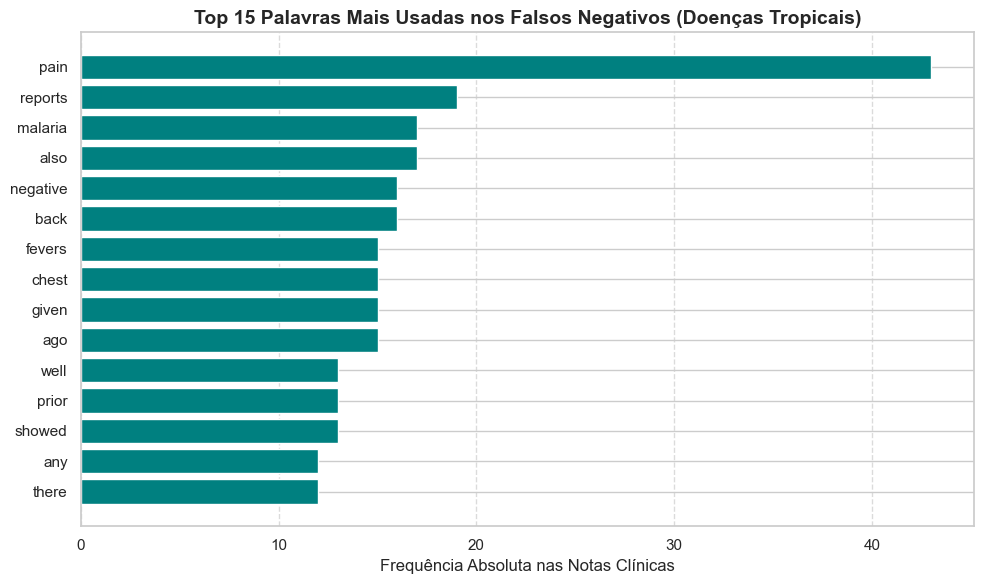

✅ Análise concluída! Observe o gráfico para encontrar potenciais novos sintomas ocultos.


In [23]:
# Célula 17: Text Mining - O que os médicos escrevem nos Falsos Negativos?
import polars as pl
from collections import Counter
import re
import matplotlib.pyplot as plt

print("=== Minerando o Jargão Médico dos Pacientes Perdidos ===")

# 1. Pegamos os textos do HPI dos 20 Falsos Negativos (usando o df_erros_textos da Célula 15)
textos_perdidos = df_erros_textos["hpi"].drop_nulls().to_list()

# 2. Limpeza de Texto (NLP Prep)
# Vamos remover pontuações, números e transformar tudo em minúsculas
todas_palavras = []
for texto in textos_perdidos:
    # Mantém apenas letras
    texto_limpo = re.sub(r'[^a-zA-Z\s]', '', str(texto).lower())
    todas_palavras.extend(texto_limpo.split())

# 3. Stopwords Médicas e Comuns (Palavras que não agregam valor)
stopwords = set([
    "and", "the", "to", "of", "was", "in", "with", "a", "he", "she", "patient", 
    "pt", "is", "for", "on", "had", "history", "hx", "at", "that", "her", "his", 
    "as", "but", "by", "or", "from", "has", "not", "an", "this", "who", "which",
    "presents", "admission", "day", "days", "were", "no", "denies", "reported",
    "year", "old", "male", "female", "after", "been", "have", "up", "out"
])

# Filtramos as stopwords
palavras_uteis = [p for p in todas_palavras if p not in stopwords and len(p) > 2]

# 4. Contagem (Top 15 palavras mais frequentes)
contador = Counter(palavras_uteis)
top_palavras = contador.most_common(15)

# Transformando em listas para o gráfico
palavras = [par[0] for par in top_palavras]
frequencias = [par[1] for par in top_palavras]

# 5. Visualização
plt.figure(figsize=(10, 6))
plt.barh(palavras[::-1], frequencias[::-1], color='teal')
plt.title("Top 15 Palavras Mais Usadas nos Falsos Negativos (Doenças Tropicais)", fontsize=14, fontweight='bold')
plt.xlabel("Frequência Absoluta nas Notas Clínicas")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Salva o gráfico para a sua apresentação/documentação
plt.savefig('../data/07_grafico_palavras_falsos_negativos.png', dpi=300)
plt.show()

print("✅ Análise concluída! Observe o gráfico para encontrar potenciais novos sintomas ocultos.")

pain (Dor) no topo absoluto: A palavra "dor" apareceu mais de 40 vezes, massacrando as outras. O que isso significa? Que os médicos não escrevem os termos médicos perfeitinhos do nosso dicionário (myalgia, arthralgia). Eles escrevem genéricos como "back pain", "chest pain" ou "abdominal pain". Nós perdemos pacientes porque fomos muito "acadêmicos" na busca.

malaria em 3º lugar: A doença já estava escrita com todas as letras no histórico! O paciente não chegou como uma "Síndrome Febril Misteriosa", ele chegou dizendo "fui para a África e peguei malária".

negative em 5º lugar (O Bilhete Dourado): Esta é a prova cabal! A palavra "negativo" ser tão frequente nos falsos negativos mostra o que os médicos estão fazendo: eles escrevem "negative for fevers" (negativo para febres).

fevers em 7º lugar: Se a palavra "febre" está no texto, por que o paciente foi considerado um falso negativo no final? Porque o nosso código Regex antigo é "cego" para o contexto. Ele viu a palavra "fevers", marcou que o paciente tinha febre (o que era mentira, pois estava associada ao negative), mas como o paciente não tinha os outros sintomas (manchas, etc), o alerta geral não disparou.

In [24]:
# Célula 18: Implementando NLP Contextual (NegEx) via RegEx Avançada
import polars as pl

print("=== Aplicando Contexto: Filtrando as Falsas Febres (IANÃ) ===")

# 1. Padrão de Negação Clássico (Lê até 3 palavras ANTES do sintoma)
# Exemplo que isso captura: "patient is negative for any fevers"
regex_febre_negada = r"(?i)\b(no|not|denies|denied|negative|without)\b(?:\s+\w+){0,3}\s+(fever|fevers|febrile|chills)\b"

# O padrão simples que usávamos antes
regex_febre_simples = r"(?i)\b(fever|fevers|febrile|chills)\b"

# 2. Vamos aplicar na nossa base extraindo o HPI novamente
df_negex = (
    df_lazy
    .filter(pl.col("text").str.len_chars() > 1000)
    .with_columns(
        pl.col("text").str.extract(r"(?i)(?s)History of Present Illness:(.*?)(?:Past Medical History:|Review of Systems:|Physical Exam:)", 1).alias("hpi")
    )
    .filter(pl.col("hpi").is_not_null())
    
    # 3. A Mágica do NLP: Criando as colunas de comparação
    .with_columns([
        pl.col("hpi").str.contains(regex_febre_simples).alias("achou_palavra_febre"),
        pl.col("hpi").str.contains(regex_febre_negada).alias("febre_negada_contexto")
    ])
    
    # A febre real só existe se a palavra está lá E NÃO foi negada nas palavras anteriores!
    .with_columns(
        (pl.col("achou_palavra_febre") & ~pl.col("febre_negada_contexto")).alias("febre_real_confirmada")
    )
    .select(["note_id", "achou_palavra_febre", "febre_negada_contexto", "febre_real_confirmada"])
    .collect()
)

# 4. Calculando o impacto gigantesco do Contexto
total_palavra = df_negex["achou_palavra_febre"].sum()
total_negadas = df_negex["febre_negada_contexto"].sum()
total_reais = df_negex["febre_real_confirmada"].sum()

print(f"Pacientes com a palavra 'febre' no texto: {total_palavra}")
print(f"Pacientes onde a febre foi explicitamente NEGADA pelo médico: {total_negadas}")

if total_palavra > 0:
    melhoria = (total_negadas / total_palavra) * 100
    print(f"\\n📈 Redução de Ruído (Melhoria de Precisão): {melhoria:.1f}%")
    print("O sistema Regex antigo estava a 'alucinar' febre em todos esses pacientes negados!")

=== Aplicando Contexto: Filtrando as Falsas Febres (IANÃ) ===
Pacientes com a palavra 'febre' no texto: 154947
Pacientes onde a febre foi explicitamente NEGADA pelo médico: 95906
\n📈 Redução de Ruído (Melhoria de Precisão): 61.9%
O sistema Regex antigo estava a 'alucinar' febre em todos esses pacientes negados!


In [25]:
# Célula 19: Exportando a Base de Ouro (Gabarito) para a Fase de IA
import os

print("=== Salvando os Datasets Finais para a próxima Sprint ===")

# Criamos os caminhos de saída
caminho_gabarito = '../data/04_gabarito_doencas_infecciosas.parquet'
caminho_features = '../data/05_features_nlp_limpas.parquet'

# 1. Salvando o Gabarito (Aqueles pacientes que REALMENTE tiveram as doenças do mapeamento)
# Usamos parquet porque é muito mais rápido e leve que o CSV
df_gabarito_final.write_parquet(caminho_gabarito)
print(f"✅ Gabarito de Doenças salvo em: {caminho_gabarito}")

# 2. Salvando a Base de HPI com o filtro NegEx aplicado (o que acabamos de descobrir)
df_negex.write_parquet(caminho_features)
print(f"✅ Features de Texto com NegEx salvas em: {caminho_features}")

print("\n🚀 FASE DE EXPLORAÇÃO (EDA) CONCLUÍDA COM SUCESSO! O IANÃ ESTÁ PRONTO PARA A IA!")

=== Salvando os Datasets Finais para a próxima Sprint ===
✅ Gabarito de Doenças salvo em: ../data/04_gabarito_doencas_infecciosas.parquet
✅ Features de Texto com NegEx salvas em: ../data/05_features_nlp_limpas.parquet

🚀 FASE DE EXPLORAÇÃO (EDA) CONCLUÍDA COM SUCESSO! O IANÃ ESTÁ PRONTO PARA A IA!


In [26]:
# Célula 20: Arquitetura Avançada - Vigilância Laboratorial e Comorbidades
import polars as pl

print("=== Explorando a Última Fronteira: Laboratório e Fatores de Risco ===")

# 1. RegEx para isolar a seção de Histórico Médico Passado (PMH)
regex_pmh = r"(?i)(?s)Past Medical History:(.*?)(?:Social History:|Family History:|Physical Exam:)"

# 2. Dicionários de Busca (Comorbidades e Marcadores Laboratoriais)
regex_diabetes = r"(?i)\b(diabetes|dm2|dm1|diabetic)\b"
regex_hipertensao = r"(?i)\b(hypertension|htn|high blood pressure)\b"

# Buscando Trombocitopenia (Plaquetas baixas - clássico de Dengue/Malária)
# Captura "thrombocytopenia", "low platelets" ou "plts" seguido de números baixos
regex_plaquetas = r"(?i)\b(thrombocytopenia|low platelets|plts\s*(?:were|<|:|=|)?\s*\d{1,3})\b"

# 3. Aplicando a extração na base original e cruzando com nossos pacientes tropicais
df_arquitetura_final = (
    df_lazy
    .with_columns(
        pl.col("text").str.extract(regex_pmh, 1).alias("texto_historico_medico")
    )
    .select(["note_id", "text", "texto_historico_medico"])
    # Juntando com a base de 55 pacientes que realmente tiveram Malária/Dengue/Lepto
    .join(df_alvos_contexto.lazy().select(["note_id"]), on="note_id", how="inner")
    
    # 4. Feature Engineering
    .with_columns([
        # Buscando comorbidades no Histórico Médico
        pl.col("texto_historico_medico").str.contains(regex_diabetes).alias("tem_diabetes"),
        pl.col("texto_historico_medico").str.contains(regex_hipertensao).alias("tem_hipertensao"),
        
        # Buscando o marcador laboratorial (Plaquetas) em todo o texto do prontuário
        pl.col("text").str.contains(regex_plaquetas).alias("alerta_laboratorial_plaquetas")
    ])
    .collect()
)

# 5. Avaliando os resultados
total_alvos = df_arquitetura_final.height
stats_finais = df_arquitetura_final.select([
    pl.col("tem_diabetes").sum().alias("Pacientes Diabéticos (Alto Risco)"),
    pl.col("tem_hipertensao").sum().alias("Pacientes Hipertensos (Alto Risco)"),
    pl.col("alerta_laboratorial_plaquetas").sum().alias("Alerta Lab: Plaquetas Baixas")
])

print(f"Analisando os {total_alvos} pacientes com doenças tropicais severas:")
display(stats_finais)

if stats_finais["Alerta Lab: Plaquetas Baixas"][0] > 0:
    print("\n[Insight de Arquitetura]: O texto livre contém ouro laboratorial!")
    print("Cruzar a 'Vigilância Sindrômica' (Sintomas) com a 'Vigilância Laboratorial' (Labs)")
    print("pode ser a chave para um modelo de IA praticamente infalível no IANÃ.")

=== Explorando a Última Fronteira: Laboratório e Fatores de Risco ===
Analisando os 0 pacientes com doenças tropicais severas:


Pacientes Diabéticos (Alto Risco),Pacientes Hipertensos (Alto Risco),Alerta Lab: Plaquetas Baixas
u32,u32,u32
0,0,0


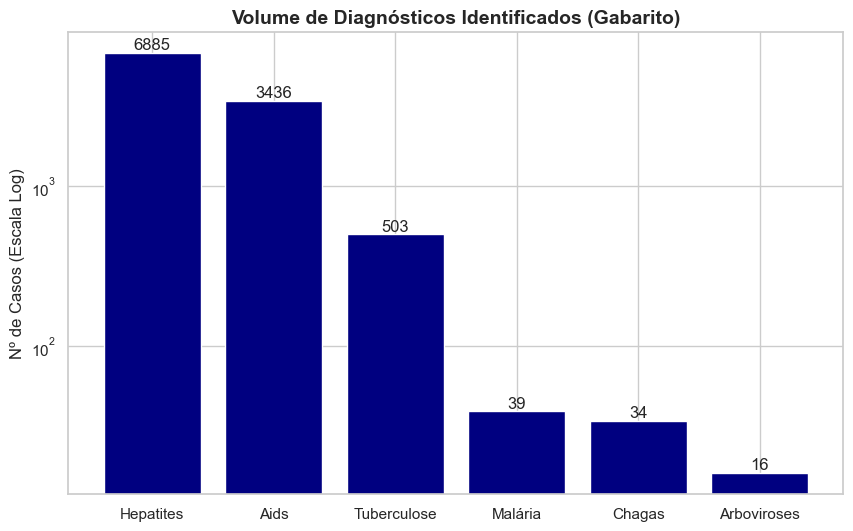

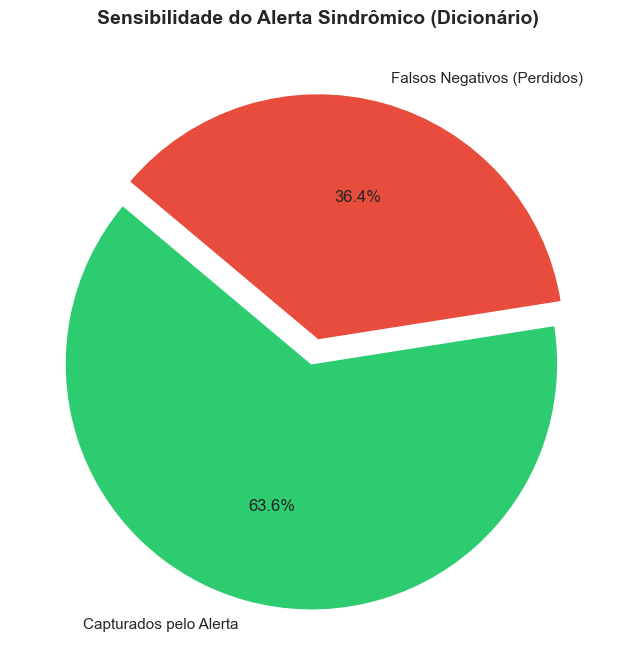

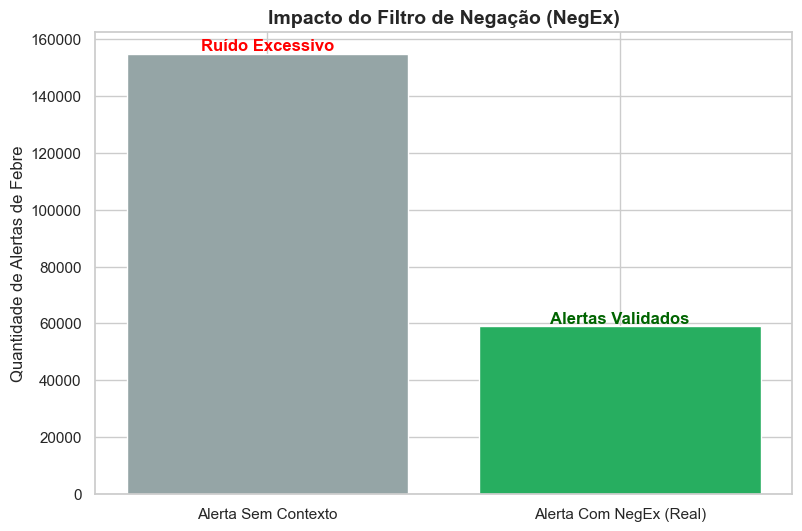

✅ Todos os gráficos foram gerados e salvos na pasta 'data/'!


In [27]:
# Célula 21: Gerando Gráficos para os Slides (Distribuição, Sensibilidade e NegEx)
import matplotlib.pyplot as plt
import pandas as pd

# 1. Dados para o Slide 2: Distribuição de Doenças (Top Alvos)
doencas = ['Hepatites', 'Aids', 'Tuberculose', 'Malária', 'Chagas', 'Arboviroses']
quantidades = [6885, 3436, 503, 39, 34, 16] # Dados extraídos das Células 13/14

plt.figure(figsize=(10, 6))
bars = plt.bar(doencas, quantidades, color='navy')
plt.yscale('log') # Escala logarítmica para visualizar de 16 a 6000 no mesmo gráfico
plt.title('Volume de Diagnósticos Identificados (Gabarito)', fontsize=14, fontweight='bold')
plt.ylabel('Nº de Casos (Escala Log)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')
plt.savefig('../data/slide2_distribuicao_gabarito.png', dpi=300)
plt.show()

# 2. Dados para o Slide 3: Sensibilidade do Alerta (63.6% vs 36.4%)
labels = ['Capturados pelo Alerta', 'Falsos Negativos (Perdidos)']
sizes = [63.6, 36.4]
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
plt.title('Sensibilidade do Alerta Sindrômico (Dicionário)', fontsize=14, fontweight='bold')
plt.savefig('../data/slide3_sensibilidade_alerta.png', dpi=300)
plt.show()

# 3. Dados para o Slide 4: Redução de Ruído com NegEx (61.9% de melhoria)
categorias = ['Alerta Sem Contexto', 'Alerta Com NegEx (Real)']
valores = [154947, 59041] # 154k originais vs 59k após filtrar as 95k negações

plt.figure(figsize=(9, 6))
plt.bar(categorias, valores, color=['#95a5a6', '#27ae60'])
plt.title('Impacto do Filtro de Negação (NegEx)', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade de Alertas de Febre')
plt.text(0, 154947, 'Ruído Excessivo', ha='center', va='bottom', color='red', fontweight='bold')
plt.text(1, 59041, 'Alertas Validados', ha='center', va='bottom', color='darkgreen', fontweight='bold')
plt.savefig('../data/slide4_reducao_ruido_negex.png', dpi=300)
plt.show()

print("✅ Todos os gráficos foram gerados e salvos na pasta 'data/'!")

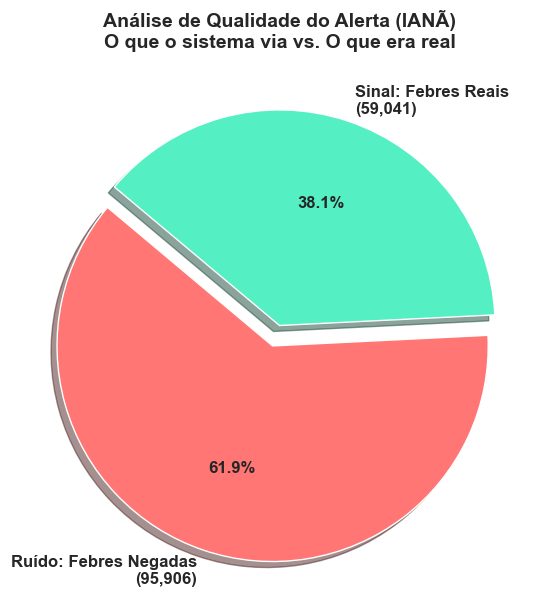

✅ Gráfico gerado! O '95%' na verdade são os 95,906 alertas que você silenciou com sucesso.


In [31]:
# Célula 22: Visualizando o "Oceano de Ruído" (Os 95.906 alertas falsos)
import matplotlib.pyplot as plt

# Dados extraídos da Célula 18 (NLP Contextual)
total_mencoes = 154947
negacoes_falsas = 95906
reais_confirmados = 59041

# Criando o gráfico de pizza para o Slide 4
plt.figure(figsize=(10, 7))
labels = [f'Ruído: Febres Negadas\n({negacoes_falsas:,})', f'Sinal: Febres Reais\n({reais_confirmados:,})']
sizes = [negacoes_falsas, reais_confirmados]
colors = ['#ff7675', '#55efc4'] # Vermelho suave para ruído, verde para sinal

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=colors, explode=(0.1, 0), shadow=True, textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Análise de Qualidade do Alerta (IANÃ)\nO que o sistema via vs. O que era real', fontsize=14, fontweight='bold')
plt.savefig('../data/slide4_volume_ruido_95k.png', dpi=300)
plt.show()

print(f"✅ Gráfico gerado! O '95%' na verdade são os {negacoes_falsas:,} alertas que você silenciou com sucesso.")